In [ ]:
# Install packages
!pip install datasets torch torchvision transformers pillow requests tqdm -q

import torch
import pickle
import numpy as np
import pandas as pd
from PIL import Image
import requests
from io import BytesIO
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("✓ Packages installed")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

✓ Packages installed
PyTorch version: 2.9.0+cu126
CUDA available: True
Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Base path - SAME FOR ALL PHASES
base_path = '/content/drive/MyDrive/CSE 941'

# Phase number - CHANGE THIS for each phase (1, 2, 3, 4, 5, or 6)
phase_num = 2  # ← CHANGE THIS

output_dir = f'{base_path}/outputs/phase{phase_num}'
plots_dir = f'{output_dir}/plots'

import os
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

print(f"✓ Working in: {base_path}")
print(f"✓ Output directory: {output_dir}")

Mounted at /content/drive
✓ Working in: /content/drive/MyDrive/CSE 941
✓ Output directory: /content/drive/MyDrive/CSE 941/outputs/phase2


In [ ]:
# Load processed data from Phase 1
phase1_path = f'{base_path}/outputs/phase1/processed_data.pkl'

with open(phase1_path, 'rb') as f:
    data = pickle.load(f)

reviews_df = data['reviews']
meta_df = data['metadata']
stats = data['stats']

print("✓ Phase 1 data loaded")
print(f"  Reviews: {len(reviews_df):,}")
print(f"  Items: {len(meta_df):,}")
print(f"  Users: {reviews_df['user_id'].nunique():,}")

✓ Phase 1 data loaded
  Reviews: 41,109
  Items: 20,223
  Users: 10,000


In [ ]:
print("Loading CLIP model...")
print("This may take 2-3 minutes...")

# Load CLIP model (using smaller ViT-B/32 for efficiency)
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

print("✓ CLIP model loaded")
print(f"  Model: {model_name}")
print(f"  Device: {device}")
print(f"  Embedding dimension: 512")

Loading CLIP model...
This may take 2-3 minutes...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✓ CLIP model loaded
  Model: openai/clip-vit-base-patch32
  Device: cuda
  Embedding dimension: 512


In [ ]:
# Extract image URLs from metadata
def get_first_image_url(images_list):
    """Extract first available image URL"""
    if not images_list or len(images_list) == 0:
        return None

    # Try different image sizes (hi_res > large > thumb)
    first_img = images_list[0]
    if 'hi_res' in first_img and first_img['hi_res']:
        return first_img['hi_res']
    elif 'large' in first_img and first_img['large']:
        return first_img['large']
    elif 'thumb' in first_img and first_img['thumb']:
        return first_img['thumb']
    return None

meta_df['image_url'] = meta_df['images'].apply(get_first_image_url)

# Filter items with valid images
items_with_images = meta_df[meta_df['image_url'].notna()].copy()

print(f"✓ Image URLs prepared")
print(f"  Total items: {len(meta_df):,}")
print(f"  Items with images: {len(items_with_images):,} ({len(items_with_images)/len(meta_df)*100:.1f}%)")

✓ Image URLs prepared
  Total items: 20,223
  Items with images: 20,223 (100.0%)


In [ ]:
def download_and_process_image(url, max_retries=2):
    """Download image and convert to PIL Image"""
    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=5)
            if response.status_code == 200:
                img = Image.open(BytesIO(response.content)).convert('RGB')
                return img
        except Exception as e:
            if attempt == max_retries - 1:
                return None
            continue
    return None

def get_clip_embedding(image, model, processor, device):
    """Get CLIP embedding for an image"""
    try:
        inputs = processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            image_features = model.get_image_features(**inputs)
        # Normalize
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        return image_features.cpu().numpy().flatten()
    except Exception as e:
        return None

print("✓ Image processing functions defined")

✓ Image processing functions defined


In [ ]:
print("Generating CLIP embeddings...")
print(f"Processing {len(items_with_images):,} items...")
print("This will take 30-60 minutes depending on connection speed...")
print()

embeddings_dict = {}
failed_items = []
batch_size = 100

# Progress tracking
total_items = len(items_with_images)
success_count = 0
fail_count = 0

for idx, row in tqdm(items_with_images.iterrows(), total=total_items, desc="Processing images"):
    asin = row['parent_asin']
    url = row['image_url']

    # Download image
    img = download_and_process_image(url)

    if img is None:
        failed_items.append(asin)
        fail_count += 1
        continue

    # Get embedding
    embedding = get_clip_embedding(img, model, processor, device)

    if embedding is not None:
        embeddings_dict[asin] = embedding
        success_count += 1
    else:
        failed_items.append(asin)
        fail_count += 1

    # Progress update every 500 items
    if (success_count + fail_count) % 500 == 0:
        print(f"  Processed: {success_count + fail_count}/{total_items} | Success: {success_count} | Failed: {fail_count}")

print("\n✓ CLIP embedding generation complete")
print(f"  Successful: {success_count:,} ({success_count/total_items*100:.1f}%)")
print(f"  Failed: {fail_count:,} ({fail_count/total_items*100:.1f}%)")

Generating CLIP embeddings...
Processing 20,223 items...
This will take 30-60 minutes depending on connection speed...




Processing images:   2%|▏         | 500/20223 [01:00<29:12, 11.25it/s]

  Processed: 500/20223 | Success: 500 | Failed: 0



Processing images:   5%|▍         | 1001/20223 [02:26<24:20, 13.16it/s]

  Processed: 1000/20223 | Success: 1000 | Failed: 0


...

  Processed: 19500/20223 | Success: 19496 | Failed: 4



Processing images:  99%|█████████▉| 20001/20223 [37:16<00:15, 14.09it/s]

  Processed: 20000/20223 | Success: 19996 | Failed: 4



Processing images: 100%|██████████| 20223/20223 [37:40<00:00,  8.95it/s]


✓ CLIP embedding generation complete
  Successful: 20,219 (100.0%)
  Failed: 4 (0.0%)


In [ ]:
# Convert to numpy array for efficient storage
embedding_matrix = np.array([embeddings_dict[asin] for asin in embeddings_dict.keys()])
asin_list = list(embeddings_dict.keys())

# Save
np.save(f'{output_dir}/clip_embeddings.npy', embedding_matrix)
np.save(f'{output_dir}/embedding_asins.npy', asin_list)

# Also save as dict for convenience
with open(f'{output_dir}/clip_embeddings_dict.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)

print("✓ Embeddings saved")
print(f"  Matrix shape: {embedding_matrix.shape}")
print(f"  File size: {os.path.getsize(f'{output_dir}/clip_embeddings.npy') / 1024**2:.2f} MB")

✓ Embeddings saved
  Matrix shape: (20219, 512)
  File size: 39.49 MB


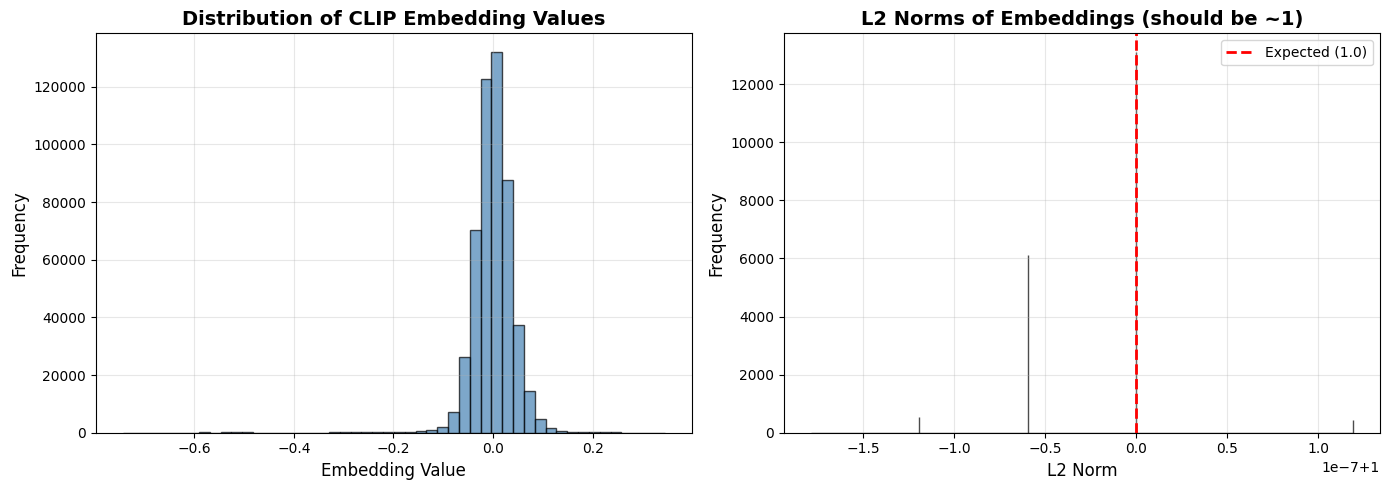

✓ Plot 1 saved
Mean L2 norm: 1.0000 (should be ~1.0)


In [ ]:
# Visualize embedding distribution
sample_embeddings = embedding_matrix[:1000]  # Sample for visualization

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of embedding values
ax[0].hist(sample_embeddings.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax[0].set_xlabel('Embedding Value', fontsize=12)
ax[0].set_ylabel('Frequency', fontsize=12)
ax[0].set_title('Distribution of CLIP Embedding Values', fontsize=14, fontweight='bold')
ax[0].grid(alpha=0.3)

# L2 norms (should be ~1 since normalized)
norms = np.linalg.norm(embedding_matrix, axis=1)
ax[1].hist(norms, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax[1].set_xlabel('L2 Norm', fontsize=12)
ax[1].set_ylabel('Frequency', fontsize=12)
ax[1].set_title('L2 Norms of Embeddings (should be ~1)', fontsize=14, fontweight='bold')
ax[1].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Expected (1.0)')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/01_embedding_quality.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 1 saved")
print(f"Mean L2 norm: {norms.mean():.4f} (should be ~1.0)")

Testing visual similarity...


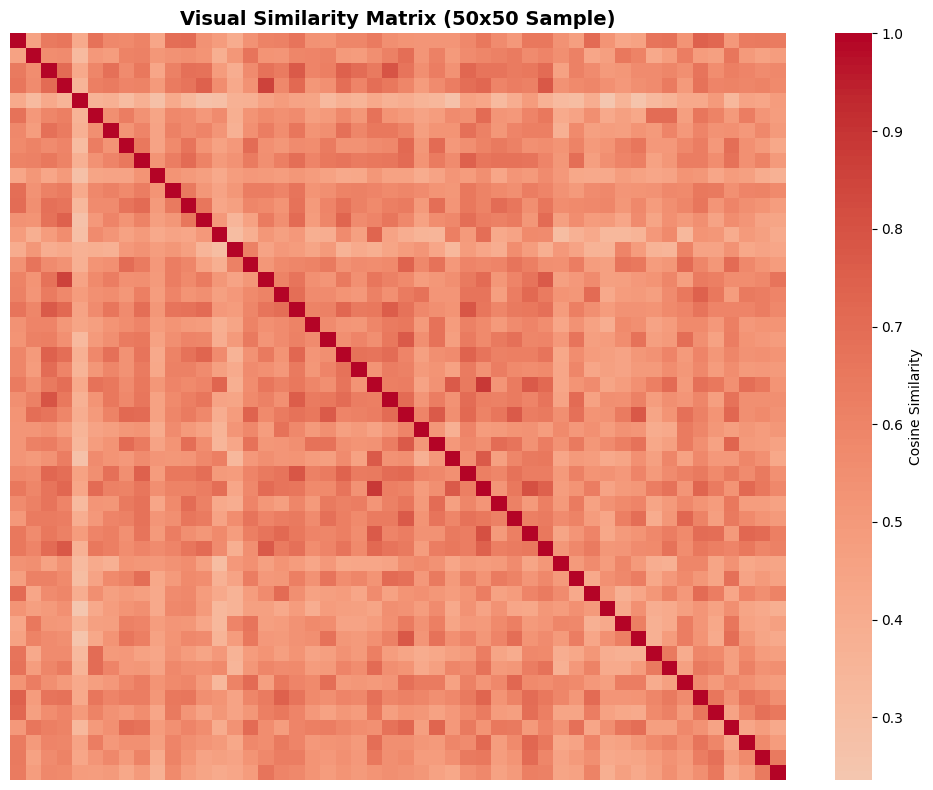

✓ Plot 2 saved
Avg similarity (off-diagonal): 0.551


In [ ]:
# Test visual similarity
print("Testing visual similarity...")

# Compute similarity matrix for sample
sample_size = min(500, len(embedding_matrix))
sample_indices = np.random.choice(len(embedding_matrix), sample_size, replace=False)
sample_emb = embedding_matrix[sample_indices]

similarity_matrix = cosine_similarity(sample_emb)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(similarity_matrix[:50, :50], cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False, ax=ax, cbar_kws={'label': 'Cosine Similarity'})
ax.set_title('Visual Similarity Matrix (50x50 Sample)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{plots_dir}/02_similarity_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 2 saved")
print(f"Avg similarity (off-diagonal): {(similarity_matrix.sum() - np.trace(similarity_matrix)) / (sample_size**2 - sample_size):.3f}")

In [ ]:
# Demonstrate similar item retrieval
def find_similar_items(target_asin, embeddings_dict, top_k=5):
    """Find most similar items to target"""
    if target_asin not in embeddings_dict:
        return []

    target_emb = embeddings_dict[target_asin].reshape(1, -1)

    similarities = {}
    for asin, emb in embeddings_dict.items():
        if asin != target_asin:
            sim = cosine_similarity(target_emb, emb.reshape(1, -1))[0, 0]
            similarities[asin] = sim

    # Sort and get top-k
    sorted_items = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return sorted_items

# Test with 3 random items
test_asins = np.random.choice(asin_list, 3, replace=False)

print("Visual Similarity Test Results:")
print("="*60)

for test_asin in test_asins:
    similar_items = find_similar_items(test_asin, embeddings_dict, top_k=5)

    # Get item info
    target_info = meta_df[meta_df['parent_asin'] == test_asin]['title'].values
    target_title = target_info[0] if len(target_info) > 0 else "Unknown"

    print(f"\nTarget Item: {test_asin}")
    print(f"Title: {target_title[:80]}...")
    print(f"\nTop 5 Similar Items:")

    for rank, (sim_asin, sim_score) in enumerate(similar_items, 1):
        sim_info = meta_df[meta_df['parent_asin'] == sim_asin]['title'].values
        sim_title = sim_info[0] if len(sim_info) > 0 else "Unknown"
        print(f"  {rank}. [{sim_score:.3f}] {sim_title[:70]}...")

    print("-"*60)

print("\n✓ Similarity test complete")

Visual Similarity Test Results:

Target Item: B06XPHN867
Title: DRESSMAKER 4X4 Free Part Lace Closure Brazilian Straight Human Hair Lace Closure...

Top 5 Similar Items:
  1. [0.929] 10A Straight Hair 1 Bundles Brazilian Virgin Human Hair Bundles Straig...
  2. [0.928] 10A Brazilian Straight Hair Bundles with Closure (14 16 18 with 12), U...
  3. [0.927] Clip in Human Hair Extensions,Natural Black Remy Hair Extensions for W...
  4. [0.926] Brazilian Straight Human Hair Bundles (20 22 24 Inch) Straight Bundles...
  5. [0.923] ALEPAZ Lace Front Wigs Human Hair Straight Lace 4x4 Closure Wigs for B...
------------------------------------------------------------

Target Item: B00KOCX9KC
Title: Ors Olive Oil Conditioner Replenishing 12.25 Ounce (362ml) (6 Pack)...

Top 5 Similar Items:
  1. [0.928] Ors Olive Oil Conditioner Replenishing 12.25 Ounce (362ml) (2 Pack)...
  2. [0.862] ORS Olive Oil Gellie Glaze and Hold 3.5 Ounce (Pack of 2)...
  3. [0.849] Ors Olive Oil Creme Relaxer Normal 18.

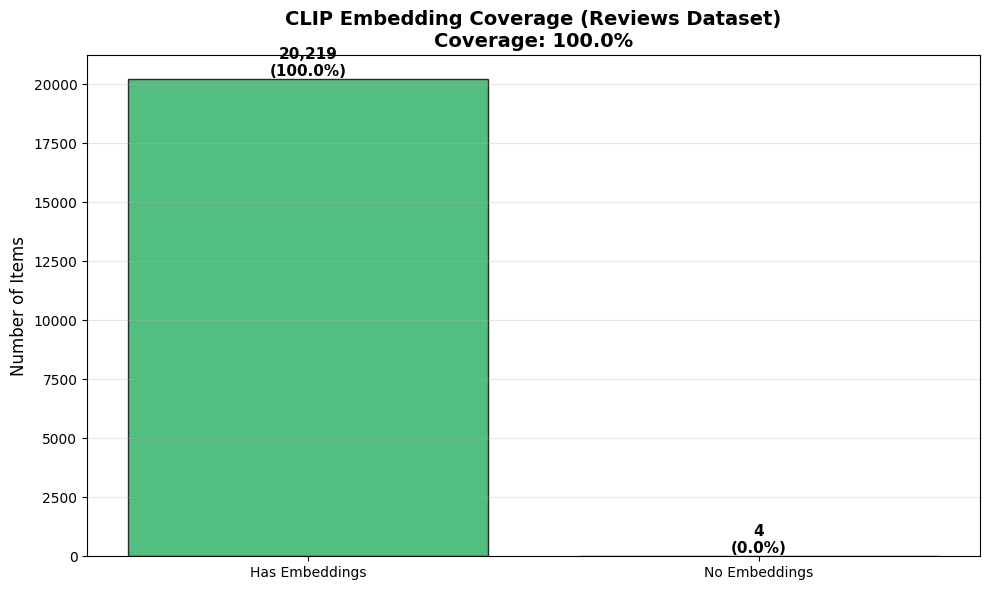

✓ Plot 3 saved
Coverage: 100.0% of items in reviews have CLIP embeddings


In [ ]:
# Analyze which items have embeddings
items_in_reviews = set(reviews_df['parent_asin'].unique())
items_with_embeddings = set(embeddings_dict.keys())

coverage = len(items_with_embeddings.intersection(items_in_reviews)) / len(items_in_reviews) * 100

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Has Embeddings', 'No Embeddings']
counts = [
    len(items_with_embeddings.intersection(items_in_reviews)),
    len(items_in_reviews - items_with_embeddings)
]

bars = ax.bar(categories, counts, color=['#27ae60', '#e74c3c'], edgecolor='black', alpha=0.8)
ax.set_ylabel('Number of Items', fontsize=12)
ax.set_title(f'CLIP Embedding Coverage (Reviews Dataset)\nCoverage: {coverage:.1f}%',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({height/sum(counts)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{plots_dir}/03_embedding_coverage.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 3 saved")
print(f"Coverage: {coverage:.1f}% of items in reviews have CLIP embeddings")

In [ ]:
from datetime import datetime

print("\n" + "="*70)
print("PHASE 2 COMPLETE - FINAL REPORT")
print("="*70)
print(f"Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

print("\n🖼️  CLIP EMBEDDING STATISTICS:")
print(f"  Model used: {model_name}")
print(f"  Embedding dimension: 512")
print(f"  Device: {device}")
print(f"  Total items processed: {len(items_with_images):,}")
print(f"  Successful embeddings: {success_count:,} ({success_count/len(items_with_images)*100:.1f}%)")
print(f"  Failed: {fail_count:,} ({fail_count/len(items_with_images)*100:.1f}%)")
print(f"  Coverage in reviews dataset: {coverage:.1f}%")

print("\n💾 SAVED ARTIFACTS:")
print(f"  ✓ Embedding matrix: {output_dir}/clip_embeddings.npy ({embedding_matrix.shape})")
print(f"  ✓ ASIN list: {output_dir}/embedding_asins.npy ({len(asin_list)} items)")
print(f"  ✓ Embeddings dict: {output_dir}/clip_embeddings_dict.pkl")
print(f"  ✓ Total size: {os.path.getsize(f'{output_dir}/clip_embeddings.npy') / 1024**2:.2f} MB")

print("\n📊 QUALITY METRICS:")
print(f"  Mean L2 norm: {norms.mean():.4f} (expected: 1.0)")
print(f"  Std L2 norm: {norms.std():.4f}")

print("\n📂 OUTPUT LOCATION:")
print(f"  {output_dir}")

print("\n✅ READY FOR PHASE 3: Graph Construction")
print("="*70)


PHASE 2 COMPLETE - FINAL REPORT
Completion Time: 2026-01-23 03:32:20

🖼️  CLIP EMBEDDING STATISTICS:
  Model used: openai/clip-vit-base-patch32
  Embedding dimension: 512
  Device: cuda
  Total items processed: 20,223
  Successful embeddings: 20,219 (100.0%)
  Failed: 4 (0.0%)
  Coverage in reviews dataset: 100.0%

💾 SAVED ARTIFACTS:
  ✓ Embedding matrix: /content/drive/MyDrive/CSE 941/outputs/phase2/clip_embeddings.npy ((20219, 512))
  ✓ ASIN list: /content/drive/MyDrive/CSE 941/outputs/phase2/embedding_asins.npy (20219 items)
  ✓ Embeddings dict: /content/drive/MyDrive/CSE 941/outputs/phase2/clip_embeddings_dict.pkl
  ✓ Total size: 39.49 MB

📊 QUALITY METRICS:
  Mean L2 norm: 1.0000 (expected: 1.0)
  Std L2 norm: 0.0000

📂 OUTPUT LOCATION:
  /content/drive/MyDrive/CSE 941/outputs/phase2

✅ READY FOR PHASE 3: Graph Construction
